Parámetros finales GD:    [1.00048867 0.49177524]
Parámetros finales Adam:  [1.00048867 0.49177524]


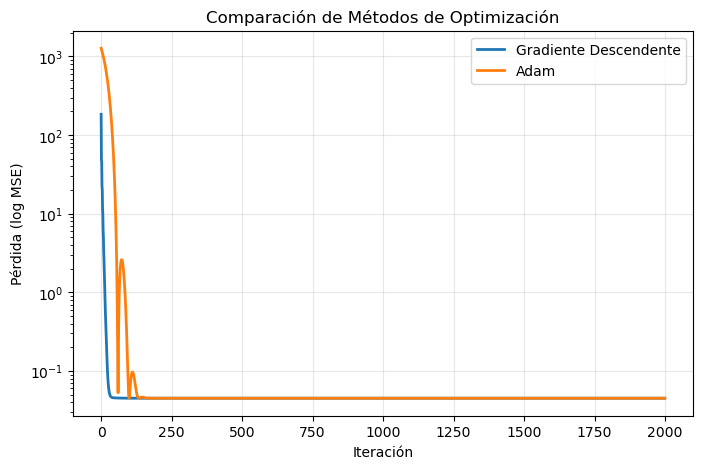

In [5]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(0)

x_data = np.linspace(1, 10, 30)
y_true = (x_data/2)**-3 + x_data**2  
y_data = y_true + np.random.normal(0, 0.2, size=x_data.shape) 


#funcion entregada 

def model(x, theta):
    theta0, theta1 = theta
    return (theta0 * x)**2 + (theta1 * x)**(-3)
    

#error cuadratico medio

def mse(theta):
    y_pred = model(x_data, theta)
    return np.mean((y_pred - y_data)**2)
    

#derivar la perdida respecto a cada parametro

def gradient(theta):
    theta0, theta1 = theta
    y_pred = model(x_data, theta)
    error = (y_pred - y_data)

    #derivadas calculadas analiticamente
    dtheta0 = np.mean(2 * error * (2 * theta0 * x_data**2))
    dtheta1 = np.mean(2 * error * (-3 * (theta1 * x_data)**(-4) * x_data))

    return np.array([dtheta0, dtheta1])


#descenso de gradiente 

theta_gd = np.array([0.5, 0.5])
alpha = 1e-4
loss_hist_gd = []

for _ in range(2000):
    grad = gradient(theta_gd)
    theta_gd -= alpha * grad
    loss_hist_gd.append(mse(theta_gd))
    

#adam

theta_adam = np.array([0.5, 0.5])
beta1, beta2 = 0.9, 0.999
eps = 1e-8
m = np.zeros(2)
v = np.zeros(2)
loss_hist_adam = []

for t in range(1, 2001):
    g = gradient(theta_adam)

    #momentos
    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * (g**2)

    #correcciones de sesgo
    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)

    #actualizacion Adam
    theta_adam -= 0.01 * m_hat / (np.sqrt(v_hat) + eps)

    loss_hist_adam.append(mse(theta_adam))


#resultados

print("Parámetros finales GD:   ", theta_gd)
print("Parámetros finales Adam: ", theta_adam)



#comparacion de las perdidas

plt.figure(figsize=(8,5))
plt.plot(loss_hist_gd, label="Gradiente Descendente", linewidth=2)
plt.plot(loss_hist_adam, label="Adam", linewidth=2)
plt.yscale("log")
plt.xlabel("Iteración")
plt.ylabel("Pérdida (log MSE)")
plt.title("Comparación de Métodos de Optimización")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
